In [191]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

# ['NVDA', 'GOOGL', 'AAPL', 'GOOG', 'MSFT', 'AMZN', 'TSM', 'AVGO', 'META', 'TSLA']

In [192]:
# here i will import the data for creating the time series
stock = 'MSFT'
data = yf.download(stock, start='2010-01-01', end='2026-01-01', interval='1d')

if isinstance(data.columns, pd.MultiIndex):
    data.columns = data.columns.get_level_values(0)

[*********************100%***********************]  1 of 1 completed


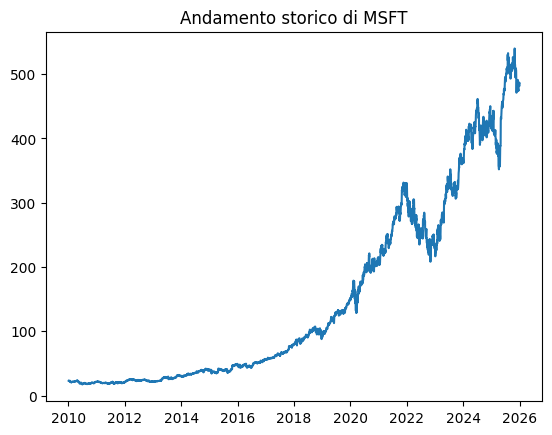

In [193]:
data = data.dropna().copy()
data.index = pd.to_datetime(data.index)
data = data.sort_index()

data.head()
plt.plot(data['Close'])
plt.title(f'Andamento storico di {stock}')
plt.show()

In [194]:
# GOLDEN CROSS

small = 50
large = 200

data['1_period_return'] = data['Close'].pct_change() # gain giornaliero

# MA 5,10,20 periodi

# data['MA_5'] = data['Close'].rolling(5).mean()
# data['MA_10'] = data['Close'].rolling(10).mean()
# data['MA_20'] = data['Close'].rolling(20).mean()

data[f'MA_{small}'] = data['Close'].rolling(small).mean()
data[f'MA_{large}'] = data['Close'].rolling(large).mean()

# volatilità small e large

data[f'vol_{small}'] = data['Close'].rolling(small).std()
data[f'vol_{large}'] = data['Close'].rolling(large).std()

In [195]:
# se valore raggiunge 3std rispetto alla rolling windows allora vendo e dopo un gain del 1% vendo
# uguale al contrario
# data = data.droplevel(1, axis=1)

window = 10 # minuti

data['mean_for_z'] = data['Close'].rolling(window).mean()
data['vol_for_z'] = data['Close'].rolling(window).std()
data['z_score'] = (data['Close']-data['mean_for_z'])/data['vol_for_z']

# colonna buy/sell
data['BS'] = 0
data.loc[data['z_score'] >= 1, 'BS'] = -1
data.loc[data['z_score'] <= -1, 'BS'] = 1

# colonna shifatata di 1 
data['delayed_1'] = data['BS'].shift(1)

In [196]:
results = []
result = 0

for i in range(len(data)):
    price = data['Close'].iloc[i]
    signal = data['delayed_1'].iloc[i]

    if result == 0:
        if signal == 1:
            result = 1
            entry_price = price
        elif signal == -1:
            result = -1
            entry_price = price

    elif result == 1:
        if abs(price-entry_price)/entry_price >= 0.01:
            result = 0

    elif result == -1:
        if abs(price-entry_price)/entry_price >= 0.01:
            result = 0

    results.append(result)

In [197]:
def sgn(n):
    if n > 0: return 1
    elif n < 0: return -1
    else: return 0

In [198]:
# INVERSIONE DI TENDENZA
# dopo 5gg di down entro long e viceversa

buys = []
buy = 0
count = 0
past_dir = None
flag = True

for i in range(len(data)):
    daily_price = data['Close'].iloc[i]
    daily_dir = sgn(data['1_period_return'].iloc[i])

    if daily_dir == past_dir:
        count += 1
    else:
        count = 1
        past_dir = daily_dir

    if buy != 0:
        if abs(start_price-daily_price)/start_price > 0.005:
            buy = 0

    if count == 3 and buy == 0:
        start_price = daily_price
        if sgn(past_dir) == 1:
            buy = -1
        else:
            buy = 1
        

    buys.append(buy)

In [199]:
data['__'] = buys
data['signal_tendecy'] = data['__'].shift(1)

In [200]:
# DENTRO ZONA +1,-1 DEV STD QUANDO ROMPE SEGUO IL MOMENTO FINO AL RITORNO ALLA MEDIA

count = 0 
signals = []
signal = 0
flag = False

for i in range(len(data)):
    z_score = data['z_score'].iloc[i]
    price = data['Close'].iloc[i]

    if signal == 0:
        if abs(z_score) <= 1:
            count += 1
        else: 
            if count >= 5:
                flag = True
            count = 0

    if flag:
        flag = False
        entry_price = data['Close'].iloc[i]
        if z_score > 1:
            signal = 1
        else: 
            signal = -1
        
    if signal != 0:
        if data['mean_for_z'].iloc[i] >= 1.02*price and signal == -1:
            signal = 0
        elif data['mean_for_z'].iloc[i] <= 0.98*price and signal == 1:
            signal = 0
            
    signals.append(signal)


In [201]:
data['___'] = signals
data['signals'] = data['___'].shift(1)

In [202]:
data['results'] = results
data['gain1'] = (1+(data['results']*data['1_period_return'])).cumprod()
data['gain2'] = (1+(data['signal_tendecy']*data['1_period_return'])).cumprod()
data['gain3'] = (1+(data['signals']*data['1_period_return'])).cumprod()

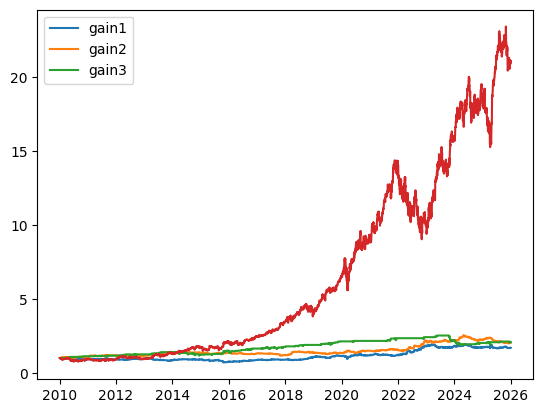

1.6908812243563698
2.0393911671167384
2.0795943971126736
19.908729367322266


In [203]:
# printiamo i dati storici
plt.plot(data['gain1'], label='gain1')
plt.plot(data['gain2'], label='gain2')
plt.plot(data['gain3'], label='gain3')

plt.legend()
plt.plot((1+data['1_period_return']).cumprod())
plt.show()

print(data['gain1'].iloc[-1])
print(data['gain2'].iloc[-1])
print(data['gain3'].iloc[-1])
print((data['Close'].iloc[-1]-data['Close'].iloc[0])/data['Close'].iloc[0])

In [204]:
# impostiasmo semplice strategia
# se MA20 è sopra alle altre due allora compro, quando si trova sotto le altre due vendo
# aggiungo colonna segnale al df

data['dec'] = 0
data.loc[(data[f'MA_{large}'] > data[f'MA_{small}']), 'dec'] = -1
data.loc[(data[f'MA_{large}'] < data[f'MA_{small}']), 'dec'] = 1

In [207]:
# compro e vendo in base a 'dec'
data['my_return'] = (1+(data['1_period_return']*data['dec'])).cumprod()
data['all_return'] = (1+data['1_period_return']).cumsum()

Vol_my: 0.04909121919422358 vs Vol_mkt: 0.02387924115026797


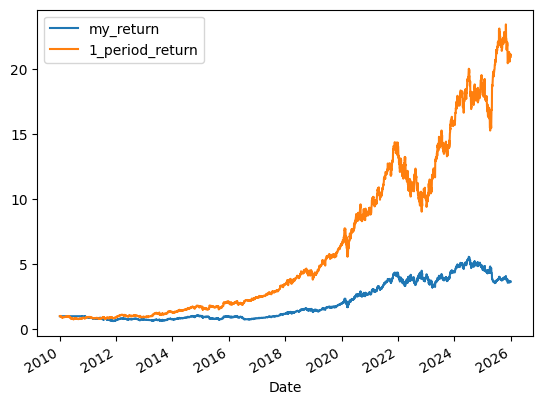

In [208]:
data['my_return'].plot()
(1+data['1_period_return']).cumprod().plot()
plt.legend()

print(f'Vol_my: {data['my_return'].rolling(20).std().mean()} vs Vol_mkt: {data['1_period_return'].cumsum().rolling(20).std().mean()}')

In [178]:
# saving = []
saving.append(data['my_return'].iloc[-1])
saving

[np.float64(-0.11572144597430256),
 np.float64(0.14051213493477166),
 np.float64(0.14140741760903996),
 np.float64(0.5929366396144568),
 np.float64(0.25414756477559064),
 np.float64(0.17015235111201832),
 np.float64(0.5526512670171315),
 np.float64(0.26688874188576106),
 np.float64(6.210770752137454)]